<a href="https://colab.research.google.com/github/imkonna/Project-KGX/blob/main/Baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Datasets

In [1]:
!pip install --upgrade numpy
!pip install pytdc
!pip install pytdc rdkit xgboost torch-geometric

  Using cached pytdc-1.1.15.tar.gz (154 kB)
  Preparing metadata (setup.py) ... done
  Using cached accelerate-0.33.0-py3-none-any.whl.metadata (18 kB)
  Using cached dataclasses-0.6-py3-none-any.whl.metadata (3.0 kB)
  Using cached datasets-2.19.2-py3-none-any.whl.metadata (19 kB)
  Using cached evaluate-0.4.2-py3-none-any.whl.metadata (9.3 kB)
  Using cached fuzzywuzzy-0.18.0-py2.py3-none-any.whl.metadata (4.9 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached transformers-4.50.3-py3-none-any.whl.metadata (39 kB)
INFO: pip is looking at multiple versions of pytdc to determine which version is compatible with other requirements. This could take a while.
  Using cached pytdc-1.1.14.tar.gz (151 kB)
  Preparing metadata (setup.py) ... done
  Using cached scikit-learn-1.2.2.tar.gz (7.3 MB)
  Installing build dependencies ... done
  Getting require

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 1.2 MB/s eta 0:00:00


In [4]:

from tdc.single_pred import Tox
from tdc.multi_pred.dti import DTI
from tdc.utils import retrieve_label_name_list

DATA_PATH = '../data'

# ============================================================
# TOXICITY DATASETS (core focus of the project)
# ============================================================

# 1. AMES — 7,255 molecules ★ START HERE
# Does this drug cause DNA mutations? (cancer risk)
# Binary classification. Clean, well-studied, good size for GNNs.
data_ames = Tox(name='AMES', path=DATA_PATH)
split_ames = data_ames.get_split()

# 2. hERG_Karim — 13,445 molecules
# Does this drug block the heart's hERG potassium channel? (fatal arrhythmia risk)
# Binary classification. Largest single-target toxicity dataset here.
data_herg = Tox(name='hERG_Karim', path=DATA_PATH)
split_herg = data_herg.get_split()

# 3. ClinTox — 1,484 molecules
# Did this drug fail clinical trials due to toxicity, or get FDA approved?
# Binary classification. Real-world outcome, not a lab assay.
data_clintox = Tox(name='ClinTox', path=DATA_PATH)
split_clintox = data_clintox.get_split()

# 4. Tox21 — 7,831 molecules × 12 targets
# US government screen across 12 toxicity pathways (nuclear receptors, stress response)
# Multi-label classification. Each molecule gets 12 binary labels.
label_list = retrieve_label_name_list('Tox21')
data_tox21 = Tox(name='Tox21', label_name=label_list[0], path=DATA_PATH)
split_tox21 = data_tox21.get_split()

# 5. DILI — 475 molecules
# Does this drug cause liver injury? #1 reason drugs get pulled from market.
# Binary classification. Very small — might be too tiny for GNNs.
data_dili = Tox(name='DILI', path=DATA_PATH)
split_dili = data_dili.get_split()

# 6. LD50_Zhu — 7,385 molecules
# What dose kills 50% of test organisms? (acute toxicity)
# Regression, not classification. Predict a continuous log-dose value.
data_ld50 = Tox(name='LD50_Zhu', path=DATA_PATH)
split_ld50 = data_ld50.get_split()


Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


Dataset: AMES

In [6]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# 1. Function to convert SMILES to Fingerprints
def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        # create 2048-position vector
        return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048))
    return np.zeros((2048,))

# 2. Prepare data for AMES dataset
print("Extracting fingerprints for AMES...")
X_train = np.array([smiles_to_fp(s) for s in split_ames['train']['Drug']])
y_train = split_ames['train']['Y'].values

X_test = np.array([smiles_to_fp(s) for s in split_ames['test']['Drug']])
y_test = split_ames['test']['Y'].values

# 3. Train with XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# 4. Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 5. Review (ROC-AUC)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print(f"\nResults for AMES Baseline:")
print(f"XGBoost ROC-AUC: {xgb_auc:.4f}")
print(f"Random Forest ROC-AUC: {rf_auc:.4f}")

Extracting fingerprints for AMES...

Results for AMES Baseline:
XGBoost ROC-AUC: 0.8809
Random Forest ROC-AUC: 0.9064


Dataset: hERG

In [7]:
# --- hERG Benchmark ---
print("Εκκίνηση hERG Baseline...")

# 1. Convert to Fingerprints
X_train_herg = np.array([smiles_to_fp(s) for s in split_herg['train']['Drug']])
y_train_herg = split_herg['train']['Y'].values
X_test_herg = np.array([smiles_to_fp(s) for s in split_herg['test']['Drug']])
y_test_herg = split_herg['test']['Y'].values

# 2. Random Forest
rf_herg = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_herg.fit(X_train_herg, y_train_herg)

# 3. Review
auc_herg = roc_auc_score(y_test_herg, rf_herg.predict_proba(X_test_herg)[:, 1])
print(f"hERG - Random Forest ROC-AUC: {auc_herg:.4f}")

Εκκίνηση hERG Baseline...
hERG - Random Forest ROC-AUC: 0.9201


In [8]:
# --- XGBoost for hERG ---
xgb_herg = XGBClassifier(n_estimators=100, n_jobs=-1, random_state=42)
xgb_herg.fit(X_train_herg, y_train_herg)
auc_xgb_herg = roc_auc_score(y_test_herg, xgb_herg.predict_proba(X_test_herg)[:, 1])
print(f"hERG - XGBoost ROC-AUC: {auc_xgb_herg:.4f}")

hERG - XGBoost ROC-AUC: 0.8970


Dataset: ClinTox

In [9]:
# --- ClinTox Benchmark ---
print("Εκκίνηση ClinTox Baseline...")

# 1. Preparation
X_train_ct = np.array([smiles_to_fp(s) for s in split_clintox['train']['Drug']])
y_train_ct = split_clintox['train']['Y'].values
X_test_ct = np.array([smiles_to_fp(s) for s in split_clintox['test']['Drug']])
y_test_ct = split_clintox['test']['Y'].values

# 2. Training
rf_ct = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_ct.fit(X_train_ct, y_train_ct)

# 3. Review
auc_ct = roc_auc_score(y_test_ct, rf_ct.predict_proba(X_test_ct)[:, 1])
print(f"ClinTox - Random Forest ROC-AUC: {auc_ct:.4f}")

Εκκίνηση ClinTox Baseline...
ClinTox - Random Forest ROC-AUC: 0.7917


In [6]:
# --- XGBoost για ClinTox ---
xgb_ct = XGBClassifier(n_estimators=100, n_jobs=-1, random_state=42)
xgb_ct.fit(X_train_ct, y_train_ct)
auc_xgb_ct = roc_auc_score(y_test_ct, xgb_ct.predict_proba(X_test_ct)[:, 1])
print(f"ClinTox - XGBoost ROC-AUC: {auc_xgb_ct:.4f}")

ClinTox - XGBoost ROC-AUC: 0.8696


Dataset: LD50

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# --- LD50 Benchmark (Regression) ---
print("Εκκίνηση LD50 Baseline...")

# 1. Preparation
X_train_ld = np.array([smiles_to_fp(s) for s in split_ld50['train']['Drug']])
y_train_ld = split_ld50['train']['Y'].values
X_test_ld = np.array([smiles_to_fp(s) for s in split_ld50['test']['Drug']])
y_test_ld = split_ld50['test']['Y'].values

# 2. Training Regressor
rf_ld = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf_ld.fit(X_train_ld, y_train_ld)

# 3. Review
preds_ld = rf_ld.predict(X_test_ld)
r2_ld = r2_score(y_test_ld, preds_ld)
rmse_ld = np.sqrt(mean_squared_error(y_test_ld, preds_ld))

print(f"LD50 - Random Forest R2 Score: {r2_ld:.4f}")
print(f"LD50 - Random Forest RMSE: {rmse_ld:.4f}")

Εκκίνηση LD50 Baseline...
LD50 - Random Forest R2 Score: 0.5835
LD50 - Random Forest RMSE: 0.6100


In [11]:
from xgboost import XGBRegressor

# --- XGBoost for LD50 ---
xgb_ld = XGBRegressor(n_estimators=100, n_jobs=-1, random_state=42)
xgb_ld.fit(X_train_ld, y_train_ld)
r2_xgb_ld = r2_score(y_test_ld, xgb_ld.predict(X_test_ld))
print(f"LD50 - XGBoost R2 Score: {r2_xgb_ld:.4f}")

LD50 - XGBoost R2 Score: 0.6046


Dataset: Tox21

In [12]:
# --- Tox21 Benchmark ---
print("Εκκίνηση Tox21 Baseline (Multi-label)...")

# Σημείωση: Το Tox21 στο TDC επιστρέφει συνήθως έναν στόχο τη φορά αν δεν οριστεί αλλιώς.
# Εδώ θα τρέξουμε τον πρώτο στόχο ως αντιπροσωπευτικό δείγμα.
X_train_t21 = np.array([smiles_to_fp(s) for s in split_tox21['train']['Drug']])
y_train_t21 = split_tox21['train']['Y'].values
X_test_t21 = np.array([smiles_to_fp(s) for s in split_tox21['test']['Drug']])
y_test_t21 = split_tox21['test']['Y'].values

# Εκπαίδευση
rf_t21 = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_t21.fit(X_train_t21, y_train_t21)

# Αξιολόγηση
auc_t21 = roc_auc_score(y_test_t21, rf_t21.predict_proba(X_test_t21)[:, 1])
print(f"Tox21 (Target 1) - Random Forest ROC-AUC: {auc_t21:.4f}")

Εκκίνηση Tox21 Baseline (Multi-label)...


[22:02:29] WARNING: not removing hydrogen atom without neighbors


Tox21 (Target 1) - Random Forest ROC-AUC: 0.7760


In [13]:
# --- XGBoost for Tox21 ---
xgb_t21 = XGBClassifier(n_estimators=100, n_jobs=-1, random_state=42)
xgb_t21.fit(X_train_t21, y_train_t21)
auc_xgb_t21 = roc_auc_score(y_test_t21, xgb_t21.predict_proba(X_test_t21)[:, 1])
print(f"Tox21 - XGBoost ROC-AUC: {auc_xgb_t21:.4f}")

Tox21 - XGBoost ROC-AUC: 0.8034


Dataset: DILI

In [14]:
# --- DILI Benchmark ---
print("Εκκίνηση DILI Baseline...")

# 1. Προετοιμασία
X_train_dili = np.array([smiles_to_fp(s) for s in split_dili['train']['Drug']])
y_train_dili = split_dili['train']['Y'].values
X_test_dili = np.array([smiles_to_fp(s) for s in split_dili['test']['Drug']])
y_test_dili = split_dili['test']['Y'].values

# 2. Εκπαίδευση
rf_dili = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_dili.fit(X_train_dili, y_train_dili)

# 3. Αξιολόγηση
auc_dili = roc_auc_score(y_test_dili, rf_dili.predict_proba(X_test_dili)[:, 1])
print(f"DILI - Random Forest ROC-AUC: {auc_dili:.4f}")

Εκκίνηση DILI Baseline...
DILI - Random Forest ROC-AUC: 0.8679


Class & Regression Imbalance -- Datasets

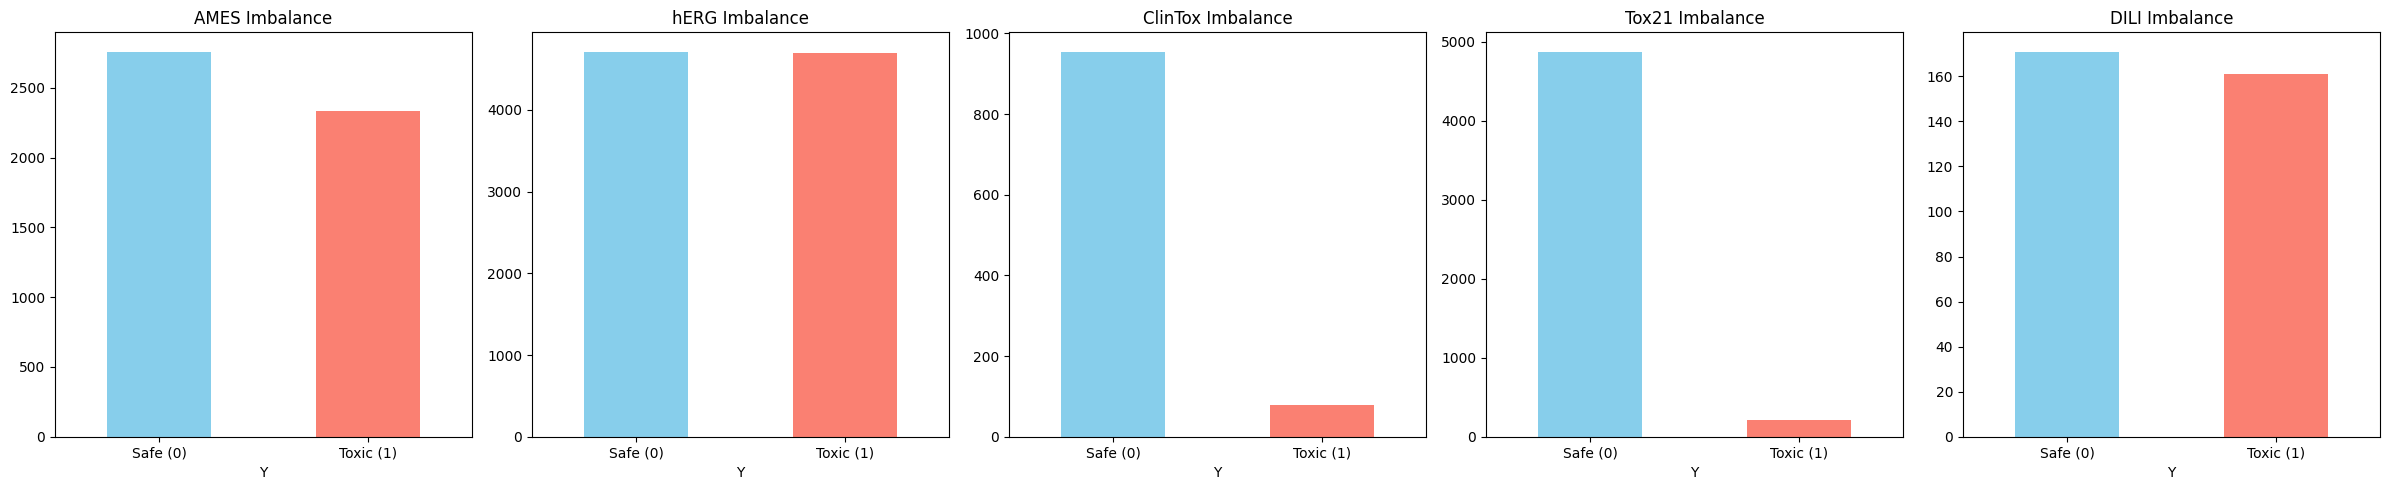

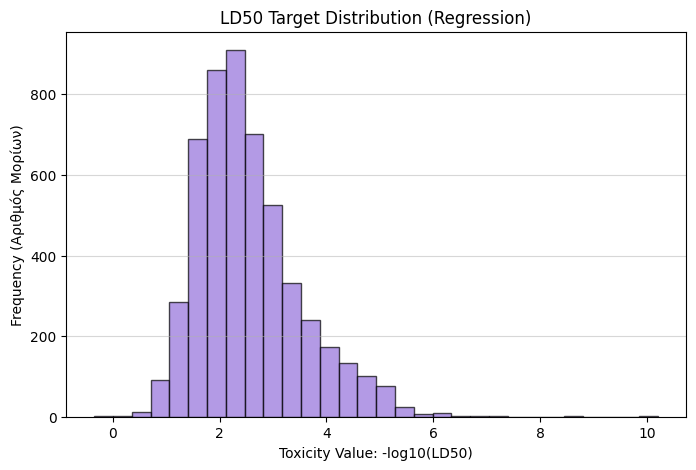

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Graphs Imbalance for the Classification Datasets ---

# List with all the classification datasets
class_datasets = {
    'AMES': split_ames,
    'hERG': split_herg,
    'ClinTox': split_clintox,
    'Tox21': split_tox21,
    'DILI': split_dili
}

# All Graphs
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for i, (name, split) in enumerate(class_datasets.items()):
    counts = split['train']['Y'].value_counts()
    counts.plot(kind='bar', ax=axes[i], color=['skyblue', 'salmon'])
    axes[i].set_title(f'{name} Imbalance')

    # We ensure that the labels are applied correctly if both classes are present
    if len(counts) == 2:
        axes[i].set_xticklabels(['Safe (0)', 'Toxic (1)'], rotation=0)

plt.tight_layout()
plt.show()

# --- 2. Histogram LD50 (Regression Dataset) ---

plt.figure(figsize=(8, 5))
split_ld50['train']['Y'].plot(kind='hist', bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
plt.title('LD50 Target Distribution (Regression)')
plt.xlabel('Toxicity Value: -log10(LD50)')
plt.ylabel('Frequency (Αριθμός Μορίων)')
plt.grid(axis='y', alpha=0.5)
plt.show()

Confusion Matrix

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Υπολογισμός προβλέψεων Baseline (ΧΩΡΙΣ Rejection Sampling)...\n")

# --- 1. Υπολογισμός προβλέψεων για το ClinTox ---
y_pred_ct = xgb_ct.predict(X_test_ct)
cm_ct = confusion_matrix(y_test_ct, y_pred_ct)

# --- 2. Υπολογισμός προβλέψεων για το Tox21 ---
y_pred_t21 = xgb_t21.predict(X_test_t21)
cm_t21 = confusion_matrix(y_test_t21, y_pred_t21)

# --- 3. Οπτικοποίηση δίπλα-δίπλα ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Γράφημα για το ClinTox
disp_ct = ConfusionMatrixDisplay(confusion_matrix=cm_ct, display_labels=['Safe (0)', 'Toxic (1)'])
disp_ct.plot(cmap='Blues', values_format='d', ax=axes[0], colorbar=False)
axes[0].set_title('Baseline Confusion Matrix - ClinTox\n(Απλό XGBoost)')

# Γράφημα για το Tox21
disp_t21 = ConfusionMatrixDisplay(confusion_matrix=cm_t21, display_labels=['Safe (0)', 'Toxic (1)'])
disp_t21.plot(cmap='Reds', values_format='d', ax=axes[1], colorbar=False)
axes[1].set_title('Baseline Confusion Matrix - Tox21\n(Απλό XGBoost)')

plt.tight_layout()
plt.show()

Υπολογισμός προβλέψεων Baseline (ΧΩΡΙΣ Rejection Sampling)...



NameError: name 'xgb_ct' is not defined

Method - Rejection Sampling

In [17]:
import numpy as np
from sklearn.base import BaseEstimator, MetaEstimatorMixin, clone
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

# --- 1. RejectionSampling Class ---
class RejectionSampling(MetaEstimatorMixin, BaseEstimator):
    def __init__(self, estimator, cost_m, random_state=None):
        self.estimator = estimator
        self.cost_m = cost_m
        self.random_state = random_state

    def fit(self, X, y):
        y_array = np.ravel(y)
        rng = np.random.RandomState(self.random_state)

        # Calculate costs: y=1 (Toxic) gets cost_m[1,0], y=0 (Safe) gets cost_m[0,1]
        costs = np.where(y_array == 1, self.cost_m[1, 0], self.cost_m[0, 1])
        max_cost = np.max(costs)
        probabilities = costs / max_cost

        # Rejection Sampling
        random_rolls = rng.rand(len(X))
        keep_mask = random_rolls < probabilities

        X_keep = X[keep_mask]
        y_keep = y_array[keep_mask]

        # Train model on the new balanced subset
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X_keep, y_keep)
        self.classes_ = self.estimator_.classes_
        return self

    def predict(self, X):
        return self.estimator_.predict(X)

    def predict_proba(self, X):
        return self.estimator_.predict_proba(X)


# --- 2. Define the Imbalanced Datasets to Run ---
# We put them in a dictionary so we can easily loop through them
imbalanced_datasets = {
    'ClinTox': (X_train_ct, X_test_ct, y_train_ct, y_test_ct),
    'Tox21': (X_train_t21, X_test_t21, y_train_t21, y_test_t21)
}

# --- 3. Loop Through and Run the Experiment ---
print("=== Starting 5-Fold CV with Rejection Sampling ===")

for name, (X_train, X_test, y_train, y_test) in imbalanced_datasets.items():
    print(f"\n---> Analyzing {name} Dataset...")

    # Combine train and test sets for K-Fold CV
    X_all = np.vstack((X_train, X_test))
    y_all = np.concatenate((y_train, y_test))

    # Calculate the exact imbalance ratio to set the cost matrix dynamically
    num_safe = np.sum(y_all == 0)
    num_toxic = np.sum(y_all == 1)
    cost_penalty = int(num_safe / num_toxic)

    print(f"Total Samples -> Safe: {num_safe}, Toxic: {num_toxic}")
    print(f"Calculated Penalty Weight for False Negatives: {cost_penalty}")

    # Define the Cost Matrix dynamically
    cost_matrix = np.array([[0, 1],                 # False Positive Cost
                            [cost_penalty, 0]])     # False Negative Cost

    # Define base model and wrap it with RejectionSampling
    base_xgb = XGBClassifier(n_estimators=100, n_jobs=-1, random_state=42)
    rj_model = RejectionSampling(estimator=base_xgb, cost_m=cost_matrix, random_state=42)

    # Define CV strategy and run
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(rj_model, X_all, y_all, cv=cv, scoring='roc_auc', n_jobs=-1)

    print(f"{name} ROC-AUC per Fold: {cv_scores}")
    print(f"{name} FINAL RELIABLE ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print("-" * 50)

=== Starting 5-Fold CV with Rejection Sampling ===

---> Analyzing ClinTox Dataset...
Total Samples -> Safe: 1227, Toxic: 103
Calculated Penalty Weight for False Negatives: 11
ClinTox ROC-AUC per Fold: [nan nan nan nan nan]
ClinTox FINAL RELIABLE ROC-AUC: nan ± nan
--------------------------------------------------

---> Analyzing Tox21 Dataset...
Total Samples -> Safe: 6267, Toxic: 272
Calculated Penalty Weight for False Negatives: 23
Tox21 ROC-AUC per Fold: [nan nan nan nan nan]
Tox21 FINAL RELIABLE ROC-AUC: nan ± nan
--------------------------------------------------


Confusion Matrix after Rejection Sampling

Generating Out-of-Fold Predictions for Confusion Matrices...



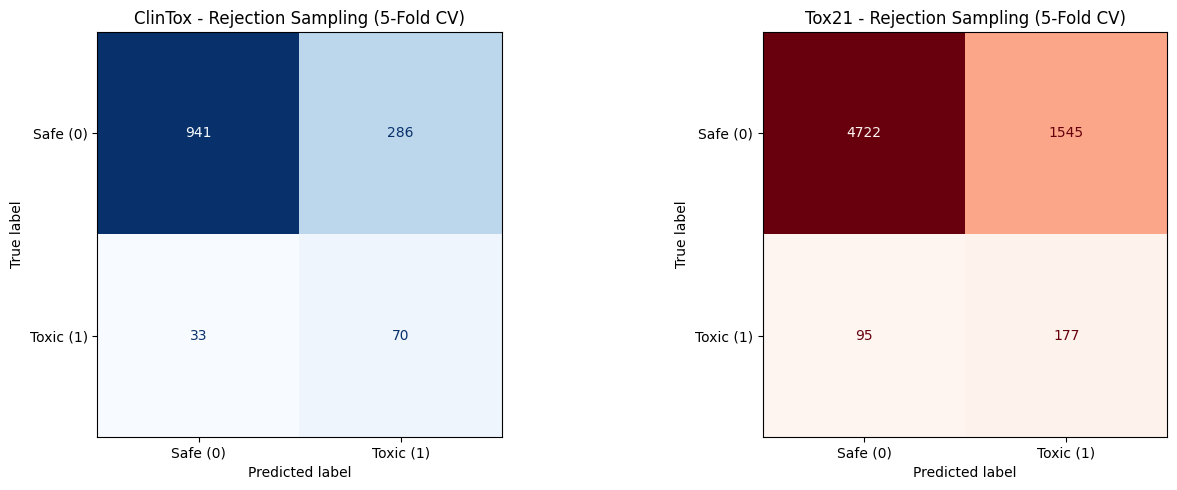

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

print("Generating Out-of-Fold Predictions for Confusion Matrices...\n")

# --- 1. Predictions for ClinTox ---
# X_all_ct and y_all_ct must be defined from your earlier cells
X_all_ct = np.vstack((X_train_ct, X_test_ct))
y_all_ct = np.concatenate((y_train_ct, y_test_ct))

num_safe_ct = np.sum(y_all_ct == 0)
num_toxic_ct = np.sum(y_all_ct == 1)
cost_matrix_ct = np.array([[0, 1], [int(num_safe_ct / num_toxic_ct), 0]])

rj_model_ct = RejectionSampling(estimator=XGBClassifier(n_estimators=100, n_jobs=-1, random_state=42),
                                cost_m=cost_matrix_ct, random_state=42)

# cross_val_predict gets the prediction for each sample when it was in the test fold
y_pred_cv_ct = cross_val_predict(rj_model_ct, X_all_ct, y_all_ct, cv=5, n_jobs=-1)
cm_ct = confusion_matrix(y_all_ct, y_pred_cv_ct)


# --- 2. Predictions for Tox21 ---
# X_all_t21 and y_all_t21 must be defined from your earlier cells
X_all_t21 = np.vstack((X_train_t21, X_test_t21))
y_all_t21 = np.concatenate((y_train_t21, y_test_t21))

num_safe_t21 = np.sum(y_all_t21 == 0)
num_toxic_t21 = np.sum(y_all_t21 == 1)
cost_matrix_t21 = np.array([[0, 1], [int(num_safe_t21 / num_toxic_t21), 0]])

rj_model_t21 = RejectionSampling(estimator=XGBClassifier(n_estimators=100, n_jobs=-1, random_state=42),
                                 cost_m=cost_matrix_t21, random_state=42)

y_pred_cv_t21 = cross_val_predict(rj_model_t21, X_all_t21, y_all_t21, cv=5, n_jobs=-1)
cm_t21 = confusion_matrix(y_all_t21, y_pred_cv_t21)


# --- 3. Plotting the Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot ClinTox
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_ct, display_labels=['Safe (0)', 'Toxic (1)'])
disp1.plot(cmap='Blues', values_format='d', ax=axes[0], colorbar=False)
axes[0].set_title('ClinTox - Rejection Sampling (5-Fold CV)')

# Plot Tox21
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_t21, display_labels=['Safe (0)', 'Toxic (1)'])
disp2.plot(cmap='Reds', values_format='d', ax=axes[1], colorbar=False)
axes[1].set_title('Tox21 - Rejection Sampling (5-Fold CV)')

plt.tight_layout()
plt.show()

Metrics

In [19]:
import numpy as np
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_predict
from xgboost import XGBClassifier

print("Υπολογισμός μετρικών για το ClinTox...\n")

# --- 1. Ενώνουμε ξανά τα δεδομένα ---
X_all_ct = np.vstack((X_train_ct, X_test_ct))
y_all_ct = np.concatenate((y_train_ct, y_test_ct))

# --- 2. Υπολογισμός Προβλέψεων (Baseline) ---
base_xgb = XGBClassifier(n_estimators=100, n_jobs=-1, random_state=42)
y_pred_base_ct = cross_val_predict(base_xgb, X_all_ct, y_all_ct, cv=5, n_jobs=-1)

# --- 3. Υπολογισμός Προβλέψεων (Rejection Sampling) ---
# Βρίσκουμε αυτόματα το penalty
cost_ct = int(np.sum(y_all_ct == 0) / np.sum(y_all_ct == 1))
rj_ct = RejectionSampling(estimator=base_xgb, cost_m=np.array([[0, 1], [cost_ct, 0]]), random_state=42)
y_pred_rj_ct = cross_val_predict(rj_ct, X_all_ct, y_all_ct, cv=5, n_jobs=-1)


# --- 4. Τύπωμα των Reports ---
print("======================================================")
print("             ΑΝΑΛΥΤΙΚΕΣ ΜΕΤΡΙΚΕΣ: CLINTOX             ")
print("======================================================\n")

print("--- 1. BASELINE (Απλό XGBoost) ---")
print(classification_report(y_all_ct, y_pred_base_ct, target_names=['Safe (0)', 'Toxic (1)']))

print("\n--- 2. REJECTION SAMPLING ---")
print(classification_report(y_all_ct, y_pred_rj_ct, target_names=['Safe (0)', 'Toxic (1)']))

Υπολογισμός μετρικών για το ClinTox...

             ΑΝΑΛΥΤΙΚΕΣ ΜΕΤΡΙΚΕΣ: CLINTOX             

--- 1. BASELINE (Απλό XGBoost) ---
              precision    recall  f1-score   support

    Safe (0)       0.94      0.98      0.96      1227
   Toxic (1)       0.54      0.26      0.35       103

    accuracy                           0.93      1330
   macro avg       0.74      0.62      0.66      1330
weighted avg       0.91      0.93      0.91      1330


--- 2. REJECTION SAMPLING ---
              precision    recall  f1-score   support

    Safe (0)       0.97      0.77      0.86      1227
   Toxic (1)       0.20      0.68      0.31       103

    accuracy                           0.76      1330
   macro avg       0.58      0.72      0.58      1330
weighted avg       0.91      0.76      0.81      1330



SMOTE METHOD - Synthetic Data

In [2]:
!pip install -U imbalanced-learn

Εκκίνηση 5-Fold CV με SMOTE (Συνθετικά Δεδομένα)...

     ΑΝΑΛΥΤΙΚΕΣ ΜΕΤΡΙΚΕΣ: ClinTox (SMOTE)          

              precision    recall  f1-score   support

    Safe (0)       0.93      0.93      0.93      1227
   Toxic (1)       0.20      0.20      0.20       103

    accuracy                           0.87      1330
   macro avg       0.57      0.57      0.57      1330
weighted avg       0.88      0.87      0.88      1330



     ΑΝΑΛΥΤΙΚΕΣ ΜΕΤΡΙΚΕΣ: Tox21 (SMOTE)          

              precision    recall  f1-score   support

    Safe (0)       0.98      0.97      0.97      6267
   Toxic (1)       0.37      0.46      0.41       272

    accuracy                           0.95      6539
   macro avg       0.67      0.71      0.69      6539
weighted avg       0.95      0.95      0.95      6539





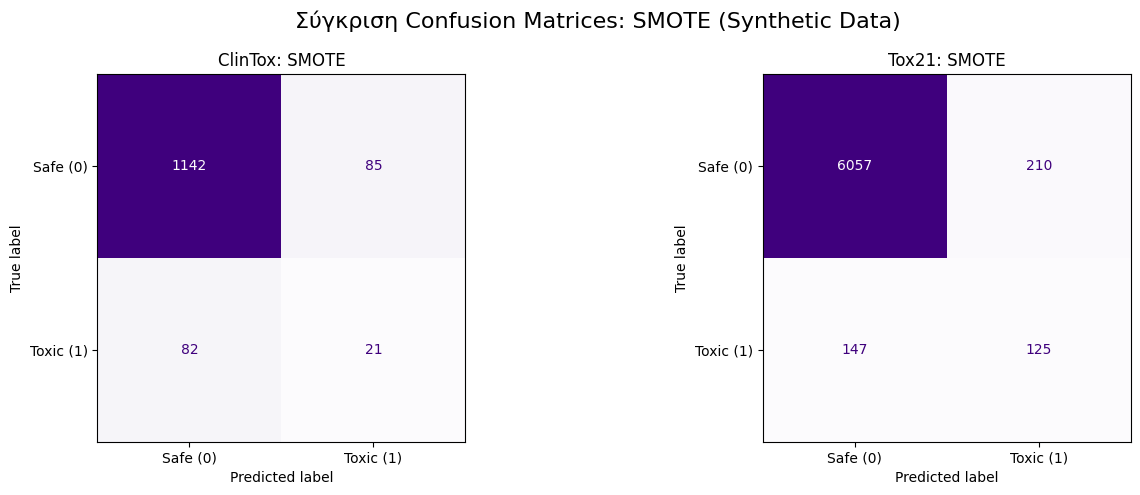

In [20]:
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

print("Εκκίνηση 5-Fold CV με SMOTE (Συνθετικά Δεδομένα)...\n")

# --- 1. Προετοιμασία Δεδομένων ---
imbalanced_datasets = {
    'ClinTox': (np.vstack((X_train_ct, X_test_ct)), np.concatenate((y_train_ct, y_test_ct))),
    'Tox21': (np.vstack((X_train_t21, X_test_t21)), np.concatenate((y_train_t21, y_test_t21)))
}

# --- 2. Στήσιμο του Pipeline (SMOTE + XGBoost) ---
# Το Pipeline εξασφαλίζει ότι το SMOTE εφαρμόζεται σωστά (χωρίς Data Leakage) σε κάθε K-Fold!
smote_xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, n_jobs=-1, random_state=42))
])

# --- 3. Εκτέλεση Πειράματος και Οπτικοποίηση ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Σύγκριση Confusion Matrices: SMOTE (Synthetic Data)', fontsize=16)

for i, (name, (X_all, y_all)) in enumerate(imbalanced_datasets.items()):

    # Υπολογισμός Προβλέψεων με 5-Fold
    y_pred_smote = cross_val_predict(smote_xgb_pipeline, X_all, y_all, cv=5, n_jobs=-1)

    print(f"==================================================")
    print(f"     ΑΝΑΛΥΤΙΚΕΣ ΜΕΤΡΙΚΕΣ: {name} (SMOTE)          ")
    print(f"==================================================\n")
    print(classification_report(y_all, y_pred_smote, target_names=['Safe (0)', 'Toxic (1)']))
    print("\n")

    # Οπτικοποίηση Confusion Matrix
    cm_smote = confusion_matrix(y_all, y_pred_smote)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=['Safe (0)', 'Toxic (1)'])
    disp.plot(cmap='Purples', values_format='d', ax=axes[i], colorbar=False)
    axes[i].set_title(f'{name}: SMOTE')

plt.tight_layout()
plt.show()